In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
import pandas as pd

df_child = pd.read_excel("놀이친구/[친구] 0~18세 인구통계.xlsx", )

df_score = pd.read_excel("[최종]진짜마지막최종_final.xlsx")
df_child = df_child.iloc[:,1:]


In [ ]:
df_child = df_child.rename(columns={
    "시군구명": "시군구",
    "읍면동명": "행정동"
})

for df in [df_child, df_score]:
    df["시군구"] = df["시군구"].astype(str).str.replace(" ", "", regex=False)
    df["행정동"] = df["행정동"].astype(str).str.strip()

child_cols = []

for age in range(0, 19):
    male_col = f"{age}세남자"
    female_col = f"{age}세여자"
    if male_col in df_child.columns:
        child_cols.append(male_col)
    if female_col in df_child.columns:
        child_cols.append(female_col)

print("사용할 아동 컬럼 수:", len(child_cols))
print(child_cols[:10])


df_child["아동인구수"] = df_child[child_cols].sum(axis=1)


df_merge = pd.merge(
    df_child,
    df_score,
    on=["시군구", "행정동"],
    how="inner"
)


df_merge["아동밀집도"] = df_merge["아동인구수"] / df_merge["아동인구수"].sum()


child_threshold = df_merge["아동밀집도"].quantile(0.7)
infra_threshold = df_merge["총점"].quantile(0.3)


df_target = df_merge[
    (df_merge["아동밀집도"] >= child_threshold) &
    (df_merge["총점"] <= infra_threshold)
].copy()

df_target = df_target.sort_values(["아동밀집도", "총점"], ascending=[False, True])

print(df_target[["시군구", "행정동", "아동인구수", "아동밀집도", "총점"]].head(20))

사용할 아동 컬럼 수: 38
['0세남자', '0세여자', '1세남자', '1세여자', '2세남자', '2세여자', '3세남자', '3세여자', '4세남자', '4세여자']
        시군구       행정동  아동인구수     아동밀집도        총점
360     강남구      대치2동   8676  0.003510  0.315555
367     강남구      개포2동   8374  0.003388  0.307573
370     강남구       세곡동   7744  0.003133  0.308664
682  부천시소사구       옥길동   7563  0.003060  0.269109
363     강남구      역삼2동   7128  0.002884  0.337588
429      중구      영종2동   6893  0.002789  0.371479
340     서초구      반포1동   6514  0.002635  0.296642
338     서초구       잠원동   6449  0.002609  0.300176
365     강남구      도곡2동   6448  0.002609  0.317561
359     강남구      대치1동   6364  0.002575  0.325695
341     서초구      반포2동   6306  0.002551  0.302123
398     송파구      잠실4동   6300  0.002549  0.364497
397     송파구      잠실3동   6224  0.002518  0.366618
651  안양시동안구      호계1동   6079  0.002459  0.341354
769    남양주시  화도읍남부출장소   6010  0.002432  0.360903
337     서초구      서초4동   5989  0.002423  0.296104
349     서초구      양재1동   5893  0.002384  0.293310
681  부천시소사구       범박동

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False

=== 카테고리별 평균 기여 비중(%) ===
안전_지수    51.33
건강_지수    20.47
환경_지수    17.21
교육_지수     9.89
복지_지수     1.10
dtype: float64


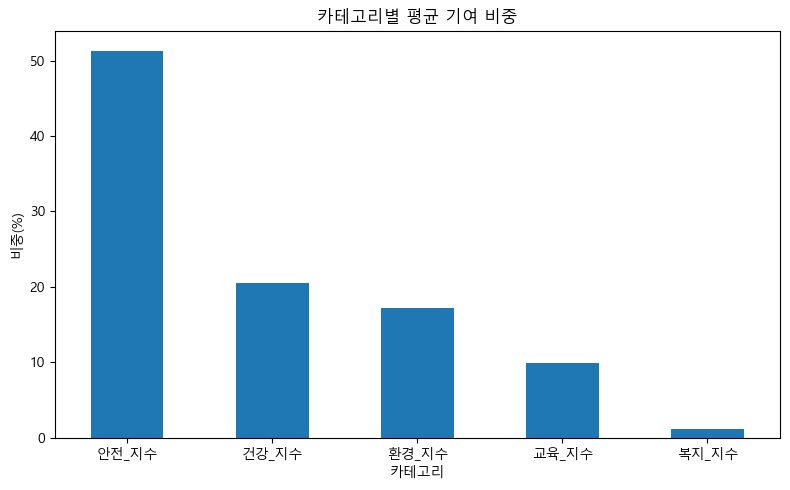


=== 카테고리별 총점 상관 기반 영향도 ===
안전_지수    0.8555
건강_지수    0.6503
교육_지수    0.3247
환경_지수    0.1802
복지_지수    0.0376
Name: 총점, dtype: float64


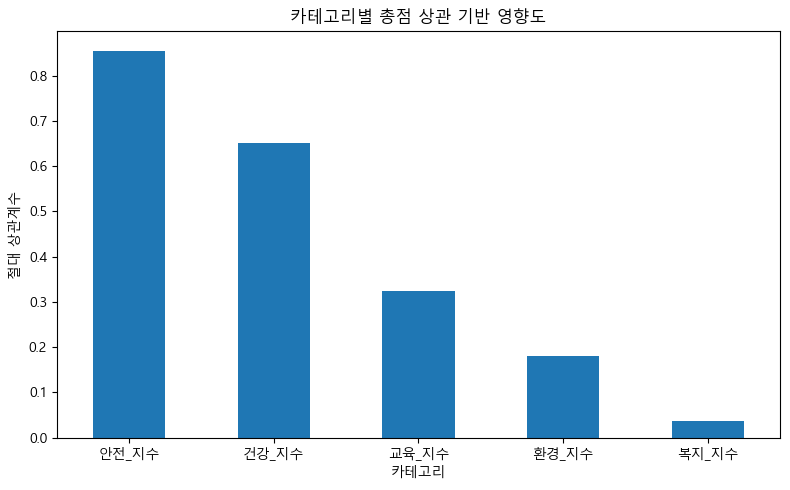

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"[최종]진짜마지막최종_final.xlsx"
df = pd.read_excel(file_path)

category_cols = ["복지_지수", "안전_지수", "교육_지수", "환경_지수", "건강_지수"]

ratio_df = df[category_cols].div(df["총점"], axis=0)

impact_ratio = ratio_df.mean() * 100
impact_ratio = impact_ratio.sort_values(ascending=False)

print("=== 카테고리별 평균 기여 비중(%) ===")
print(impact_ratio.round(2))

plt.figure(figsize=(8, 5))
impact_ratio.plot(kind="bar")
plt.title("카테고리별 평균 기여 비중")
plt.ylabel("비중(%)")
plt.xlabel("카테고리")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


impact_corr = df[category_cols + ["총점"]].corr()["총점"].drop("총점")
impact_corr = impact_corr.abs().sort_values(ascending=False)

print("\n=== 카테고리별 총점 상관 기반 영향도 ===")
print(impact_corr.round(4))

plt.figure(figsize=(8, 5))
impact_corr.plot(kind="bar")
plt.title("카테고리별 총점 상관 기반 영향도")
plt.ylabel("절대 상관계수")
plt.xlabel("카테고리")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

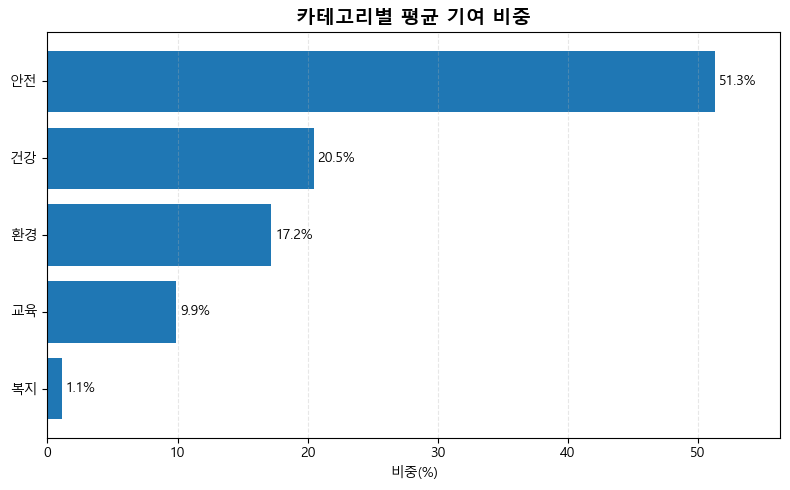

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel("[최종]진짜마지막최종_final.xlsx")

category_cols = ["복지_지수", "안전_지수", "교육_지수", "환경_지수", "건강_지수"]

name_map = {
    "복지_지수": "복지",
    "안전_지수": "안전",
    "교육_지수": "교육",
    "환경_지수": "환경",
    "건강_지수": "건강"
}


ratio_df = df[category_cols].div(df["총점"], axis=0)
impact_ratio = (ratio_df.mean() * 100).sort_values(ascending=True)
impact_ratio.index = impact_ratio.index.map(name_map)


plt.figure(figsize=(8, 5))
bars = plt.barh(impact_ratio.index, impact_ratio.values)


for i, v in enumerate(impact_ratio.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=10)

plt.title("카테고리별 평균 기여 비중", fontsize=14, weight='bold')
plt.xlabel("비중(%)")
plt.ylabel("")
plt.xlim(0, impact_ratio.max() + 5)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

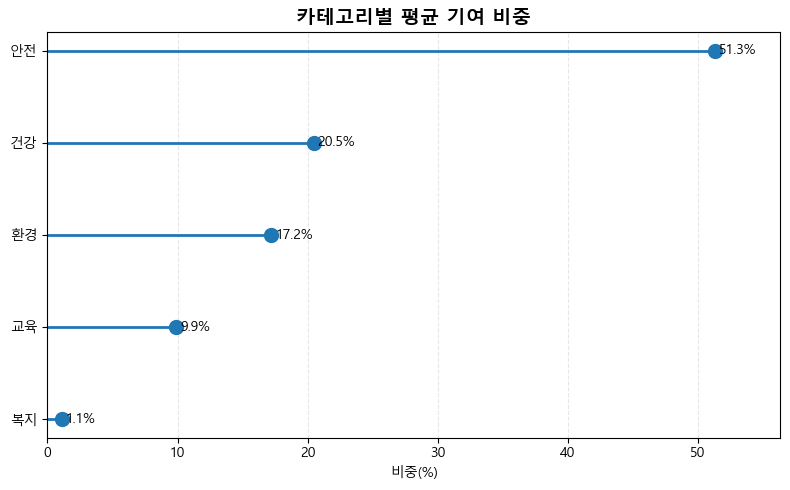

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel("[최종]진짜마지막최종_final.xlsx")

category_cols = ["복지_지수", "안전_지수", "교육_지수", "환경_지수", "건강_지수"]

name_map = {
    "복지_지수": "복지",
    "안전_지수": "안전",
    "교육_지수": "교육",
    "환경_지수": "환경",
    "건강_지수": "건강"
}

ratio_df = df[category_cols].div(df["총점"], axis=0)
impact_ratio = (ratio_df.mean() * 100).sort_values()
impact_ratio.index = impact_ratio.index.map(name_map)

plt.figure(figsize=(8, 5))

plt.hlines(y=impact_ratio.index, xmin=0, xmax=impact_ratio.values, linewidth=2)
plt.plot(impact_ratio.values, impact_ratio.index, "o", markersize=10)

for i, v in enumerate(impact_ratio.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=10)

plt.title("카테고리별 평균 기여 비중", fontsize=14, weight='bold')
plt.xlabel("비중(%)")
plt.ylabel("")
plt.xlim(0, impact_ratio.max() + 5)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

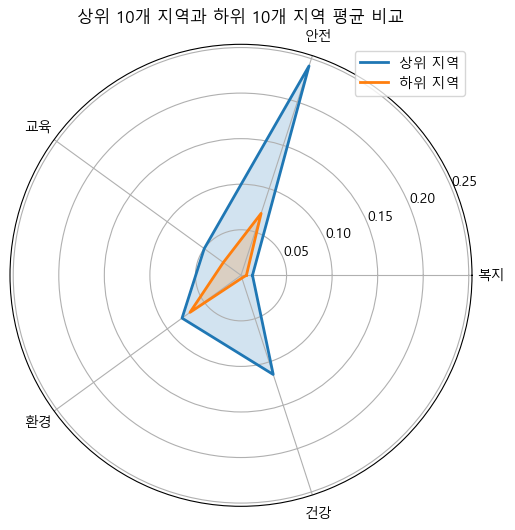

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel("[최종]진짜마지막최종_final.xlsx")

category_cols = ["복지_지수", "안전_지수", "교육_지수", "환경_지수", "건강_지수"]


top = df.nlargest(10, "총점")[category_cols].mean()
bottom = df.nsmallest(10, "총점")[category_cols].mean()

labels = ["복지", "안전", "교육", "환경", "건강"]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))


top_values = np.concatenate((top.values, [top.values[0]]))
bottom_values = np.concatenate((bottom.values, [bottom.values[0]]))


fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

ax.plot(angles, top_values, label="상위 지역", linewidth=2)
ax.fill(angles, top_values, alpha=0.2)

ax.plot(angles, bottom_values, label="하위 지역", linewidth=2)
ax.fill(angles, bottom_values, alpha=0.2)

ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)

plt.title("상위 10개 지역과 하위 10개 지역 평균 비교")
plt.legend()
plt.show()

[로드 완료] 놀이_도서관: 전체 395행 / 매칭가능 395행
[로드 완료] 놀이_놀이터: 전체 25858행 / 매칭가능 0행
[로드 완료] 놀이_키즈카페: 전체 339행 / 매칭가능 0행
[로드 완료] 복지_문화시설: 전체 476행 / 매칭가능 476행
[로드 완료] 복지_지역아동센터: 전체 900행 / 매칭가능 0행
[로드 완료] 의료_병원: 전체 32896행 / 매칭가능 32532행
[로드 완료] 의료_소아과: 전체 1545행 / 매칭가능 0행
[로드 완료] 환경_공원: 전체 4322행 / 매칭가능 0행
[로드 완료] 생활_대형마트: 전체 1200행 / 매칭가능 0행
[로드 완료] 생활_버스: 전체 39460행 / 매칭가능 0행
[로드 완료] 생활_지하철: 전체 559행 / 매칭가능 0행
[로드 완료] 교육_초등학교: 전체 1459행 / 매칭가능 0행
[로드 완료] 교육_중학교: 전체 848행 / 매칭가능 0행
[로드 완료] 교육_학원: 전체 52603행 / 매칭가능 0행
[로드 완료] 교육_어린이집: 전체 8866행 / 매칭가능 0행
[로드 완료] 교육_방과후돌봄교실: 전체 1421행 / 매칭가능 0행
[로드 완료] 안전_경찰서: 전체 59행 / 매칭가능 0행
[로드 완료] 안전_지구대: 전체 461행 / 매칭가능 0행
[로드 완료] 치안_cctv: 전체 94443행 / 매칭가능 0행
[로드 완료] 치안_알람벨: 전체 47927행 / 매칭가능 0행


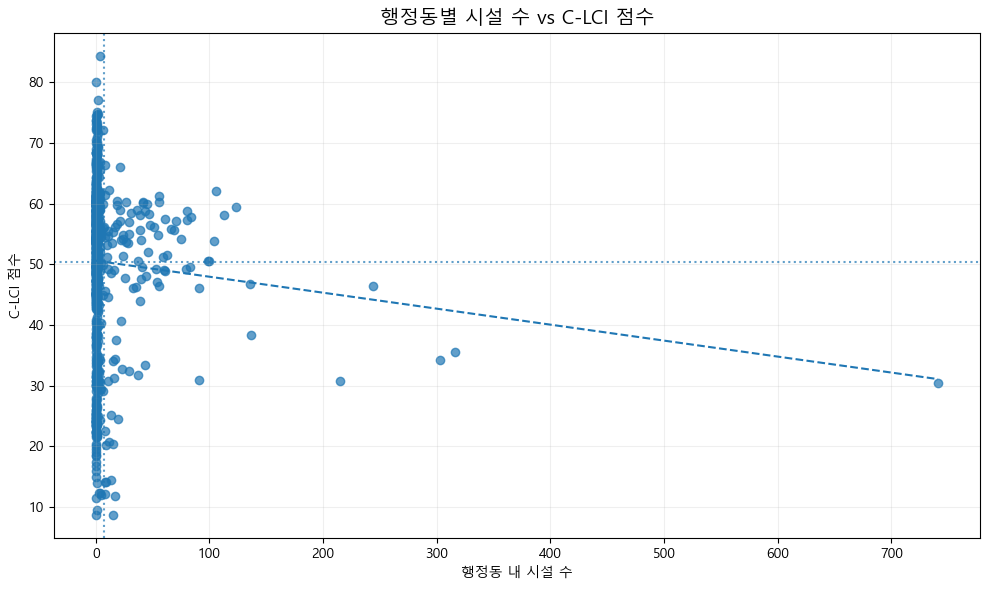


[사분면별 개수]
사분면
시설 적지만 점수 높음    471
시설 적고 점수 낮음     283
시설 많고 점수 높음      59
시설 많지만 점수 낮음     50
Name: count, dtype: int64

[시설 적지만 점수 높은 동 상위 10개]
     시군구   행정동  시설수    100점 환산
0    연수구  송도2동  4.0  84.378765
2     동구  송림2동  0.0  80.035632
1    연수구  송도1동  2.0  77.127319
9     서구  가좌3동  1.0  75.076918
4    연수구  동춘2동  2.0  74.752663
362  강서구  가양1동  1.0  74.597702
6    연수구  연수1동  1.0  74.509528
5    연수구  송도3동  0.0  74.359450
7    연수구  연수2동  0.0  73.680370
626  관악구   중앙동  0.0  73.605257

[시설 많지만 점수 낮은 동 상위 10개]
     시군구          행정동   시설수    100점 환산
861  종로구          평창동  15.0   8.594515
852  종로구          혜화동  17.0  11.754199
857  종로구          부암동   8.0  12.087079
555  종로구          이화동   9.0  14.041670
853  종로구          가회동   8.0  14.072939
855  종로구          사직동  13.0  14.423816
817  용산구          용문동   9.0  20.267227
848  종로구  종로1·2·3·4가동  15.0  20.378824
847  종로구          삼청동  12.0  20.717244
840  용산구          남영동   8.0  22.520046

[시설수 0인 행정동 개수]
468

저장 완료: 시설수_vs_CLCI_분석결과.xlsx


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def clean_sigungu(s):
    if pd.isna(s):
        return None
    return str(s).strip().replace(" ", "")

def clean_dong(s):
    if pd.isna(s):
        return None
    s = str(s).strip().replace(" ", "")
    s = s.replace(".", "·")
    return s

score_df = pd.read_excel("[최종]진짜마지막최종_final.xlsx")

score_df["시군구"] = score_df["시군구"].apply(clean_sigungu)
score_df["행정동"] = score_df["행정동"].apply(clean_dong)

score_col = "100점 환산"

score_df = score_df[["시군구", "행정동", score_col]].copy()


facility_files = {
    "놀이_도서관": "놀이친구/[놀이] 공공도서관.xlsx",
    "놀이_놀이터": "놀이친구/[놀이] 놀이터.xlsx",
    "놀이_키즈카페": "놀이친구/[놀이] 키즈카페.xlsx",
    "복지_문화시설": "의료복지/[복지]_문화시설_총합_최종.xlsx",
    "복지_지역아동센터": "의료복지/[복지]통합지역아동센터_최종.xlsx",
    "의료_병원": "의료복지/[의료]병원_최종.xlsx",
    "의료_소아과": "의료복지/[의료]주변소아과중복제거.xlsx",
    "환경_공원": "환경생활/[환경]_공원(면적포함).csv",
    "생활_대형마트": "환경생활/[생활]_대형마트모음.xlsx",
    "생활_버스": "환경생활/[생활]버스정류장.xlsx",
    "생활_지하철": "환경생활/[생활]지하철_최종.xlsx",
    "교육_초등학교": "교육학군/[교육] 초등학교.csv",
    "교육_중학교": "교육학군/[교육] 중학교.csv",
    "교육_학원": "교육학군/[교육] 학원.csv",
    "교육_어린이집": "교육학군/어린이집.csv",
    "교육_방과후돌봄교실": "교육학군/[교육] 방과후돌봄교실.csv",
    "안전_경찰서": "안전치안/[안전]경찰서위치.xlsx",
    "안전_지구대": "안전치안/[안전]지구대파출소위치.xlsx",
    "치안_cctv": "안전치안/[치안]cctv위치.xlsx",
    "치안_알람벨": "안전치안/[치안]알람벨위치.xlsx",
}

facility_dfs = []

for name, path in facility_files.items():
    try:
        if path.endswith(".csv"):
            try:
                temp = pd.read_csv(path, encoding="utf-8")
            except:
                temp = pd.read_csv(path, encoding="cp949")
        else:
            temp = pd.read_excel(path)

        temp = temp.copy()


        if "시군구" not in temp.columns:
            if "시군구명" in temp.columns:
                temp["시군구"] = temp["시군구명"]
            elif "행정구역명" in temp.columns:
                temp["시군구"] = temp["행정구역명"]
            elif "추출시군구" in temp.columns:
                temp["시군구"] = temp["추출시군구"]
            else:
                temp["시군구"] = None

        if "행정동" not in temp.columns:
            if "행정동명" in temp.columns:
                temp["행정동"] = temp["행정동명"]
            elif "읍면동" in temp.columns:
                temp["행정동"] = temp["읍면동"]
            elif "읍면동명" in temp.columns:
                temp["행정동"] = temp["읍면동명"]
            else:
                temp["행정동"] = None

        temp["시군구"] = temp["시군구"].apply(clean_sigungu)
        temp["행정동"] = temp["행정동"].apply(clean_dong)
        temp["시설종류"] = name

        temp = temp[["시군구", "행정동", "시설종류"]]
        facility_dfs.append(temp)

        valid_count = temp.dropna(subset=["시군구", "행정동"]).shape[0]
        print(f"[로드 완료] {name}: 전체 {len(temp)}행 / 매칭가능 {valid_count}행")

    except Exception as e:
        print(f"[오류] {name}: {e}")

facility_all = pd.concat(facility_dfs, ignore_index=True)


facility_count = (
    facility_all
    .dropna(subset=["시군구", "행정동"])
    .groupby(["시군구", "행정동"])
    .size()
    .reset_index(name="시설수")
)

merged = score_df.merge(
    facility_count,
    on=["시군구", "행정동"],
    how="left"
)

merged["시설수"] = merged["시설수"].fillna(0)

x = merged["시설수"]
y = merged[score_col]

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.7)

if len(merged) >= 2 and x.nunique() >= 2:
    coef = np.polyfit(x, y, 1)
    poly1d_fn = np.poly1d(coef)

    x_sorted = np.sort(x)
    plt.plot(x_sorted, poly1d_fn(x_sorted), linestyle="--")

x_mean = x.mean()
y_mean = y.mean()
plt.axvline(x=x_mean, linestyle=":", alpha=0.7)
plt.axhline(y=y_mean, linestyle=":", alpha=0.7)

plt.title("행정동별 시설 수 vs C-LCI 점수", fontsize=14)
plt.xlabel("행정동 내 시설 수")
plt.ylabel("C-LCI 점수")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

def quadrant(row):
    if row["시설수"] >= x_mean and row[score_col] >= y_mean:
        return "시설 많고 점수 높음"
    elif row["시설수"] < x_mean and row[score_col] >= y_mean:
        return "시설 적지만 점수 높음"
    elif row["시설수"] >= x_mean and row[score_col] < y_mean:
        return "시설 많지만 점수 낮음"
    else:
        return "시설 적고 점수 낮음"

merged["사분면"] = merged.apply(quadrant, axis=1)

print("\n[사분면별 개수]")
print(merged["사분면"].value_counts())

print("\n[시설 적지만 점수 높은 동 상위 10개]")
print(
    merged[merged["사분면"] == "시설 적지만 점수 높음"]
    .sort_values(score_col, ascending=False)
    .head(10)[["시군구", "행정동", "시설수", score_col]]
)

print("\n[시설 많지만 점수 낮은 동 상위 10개]")
print(
    merged[merged["사분면"] == "시설 많지만 점수 낮음"]
    .sort_values(score_col, ascending=True)
    .head(10)[["시군구", "행정동", "시설수", score_col]]
)

print("\n[시설수 0인 행정동 개수]")
print((merged["시설수"] == 0).sum())



In [ ]:
import pandas as pd
import requests
import time
import os


KAKAO_REST_API_KEY = "YOUR_KAKAO_API_KEY"

headers = {
    "Authorization": f"KakaoAK {KAKAO_REST_API_KEY}"
}

def clean_sigungu(s):
    if pd.isna(s):
        return None
    return str(s).strip().replace(" ", "")

def clean_dong(s):
    if pd.isna(s):
        return None
    s = str(s).strip().replace(" ", "")
    s = s.replace(".", "·")
    return s

def get_region_from_coord(lon, lat):
    url = "https://dapi.kakao.com/v2/local/geo/coord2regioncode.json"
    params = {
        "x": lon,
        "y": lat
    }

    try:
        r = requests.get(url, headers=headers, params=params, timeout=5)
        r.raise_for_status()
        data = r.json()

        docs = data.get("documents", [])
        if not docs:
            return None, None, None

        h_doc = None
        b_doc = None

        for doc in docs:
            if doc.get("region_type") == "H" and h_doc is None:
                h_doc = doc
            elif doc.get("region_type") == "B" and b_doc is None:
                b_doc = doc

        if h_doc:
            sido = h_doc.get("region_1depth_name")
            sigungu = h_doc.get("region_2depth_name")
            dong = h_doc.get("region_3depth_name")
            return sido, sigungu, dong

        if b_doc:
            sido = b_doc.get("region_1depth_name")
            sigungu = b_doc.get("region_2depth_name")
            dong = b_doc.get("region_3depth_name")
            return sido, sigungu, dong

        return None, None, None

    except Exception as e:
        print(f"    [API 오류] lon={lon}, lat={lat}, error={e}")
        return None, None, None

def find_coord_columns(df):
    lon_candidates = ["경도", "x", "X", "longitude", "lon", "lng"]
    lat_candidates = ["위도", "y", "Y", "latitude", "lat"]

    lon_col = None
    lat_col = None

    for col in df.columns:
        if col in lon_candidates:
            lon_col = col
        if col in lat_candidates:
            lat_col = col

    return lon_col, lat_col


def ensure_region_columns(df):
    if "시도명" not in df.columns:
        if "시도" in df.columns:
            df["시도명"] = df["시도"]
        else:
            df["시도명"] = None

    if "시군구" not in df.columns:
        if "시군구명" in df.columns:
            df["시군구"] = df["시군구명"]
        elif "행정구역명" in df.columns:
            df["시군구"] = df["행정구역명"]
        elif "추출시군구" in df.columns:
            df["시군구"] = df["추출시군구"]
        else:
            df["시군구"] = None


    if "행정동" not in df.columns:
        if "행정동명" in df.columns:
            df["행정동"] = df["행정동명"]
        elif "읍면동" in df.columns:
            df["행정동"] = df["읍면동"]
        elif "읍면동명" in df.columns:
            df["행정동"] = df["읍면동명"]
        else:
            df["행정동"] = None

    return df

def process_file(path):
    print(f"\n[처리 시작] {path}")

    if path.endswith(".csv"):
        try:
            df = pd.read_csv(path, encoding="utf-8")
        except:
            df = pd.read_csv(path, encoding="cp949")
    else:
        df = pd.read_excel(path)

    df = df.copy()

    df = ensure_region_columns(df)
    lon_col, lat_col = find_coord_columns(df)

    if lon_col is None or lat_col is None:
        print("  → 좌표 컬럼 없음, 스킵")
        return

    df["시도명"] = df["시도명"].astype("object")
    df["시군구"] = df["시군구"].astype("object")
    df["행정동"] = df["행정동"].astype("object")

    df["시군구"] = df["시군구"].apply(clean_sigungu)
    df["행정동"] = df["행정동"].apply(clean_dong)

    need_mask = df["시군구"].isna() | df["행정동"].isna()

    target_df = df.loc[need_mask, [lon_col, lat_col]].dropna().drop_duplicates()

    print(f"  → API 대상 좌표 수: {len(target_df)}")

    coord_map = {}

    for _, row in target_df.iterrows():
        lon = row[lon_col]
        lat = row[lat_col]
        key = (lon, lat)

        sido, sigungu, dong = get_region_from_coord(lon, lat)
        coord_map[key] = (sido, sigungu, dong)

        time.sleep(0.05)

    def fill_region(row):
        if pd.notna(row["시군구"]) and pd.notna(row["행정동"]):
            return row["시도명"], row["시군구"], row["행정동"]

        lon = row[lon_col]
        lat = row[lat_col]
        key = (lon, lat)

        if key in coord_map:
            api_sido, api_sigungu, api_dong = coord_map[key]

            final_sido = row["시도명"] if pd.notna(row["시도명"]) else api_sido
            final_sigungu = row["시군구"] if pd.notna(row["시군구"]) else api_sigungu
            final_dong = row["행정동"] if pd.notna(row["행정동"]) else api_dong

            return final_sido, final_sigungu, final_dong

        return row["시도명"], row["시군구"], row["행정동"]

    df[["시도명", "시군구", "행정동"]] = df.apply(
        lambda r: pd.Series(fill_region(r)), axis=1
    )

    df["시군구"] = df["시군구"].apply(clean_sigungu)
    df["행정동"] = df["행정동"].apply(clean_dong)

    matched_count = df.dropna(subset=["시군구", "행정동"]).shape[0]
    print(f"  → 최종 매칭 가능 행 수: {matched_count} / {len(df)}")

    if path.endswith(".csv"):
        save_path = path[:-4] + "_행정동완료.csv"
        df.to_csv(save_path, index=False, encoding="utf-8-sig")
    else:
        save_path = path[:-5] + "_행정동완료.xlsx"
        df.to_excel(save_path, index=False)

    print(f"  → 저장 완료: {save_path}")

facility_files = {
    "놀이_도서관": "놀이친구/[놀이] 공공도서관.xlsx",
    "놀이_놀이터": "놀이친구/[놀이] 놀이터.xlsx",
    "놀이_키즈카페": "놀이친구/[놀이] 키즈카페.xlsx",
    "복지_문화시설": "의료복지/[복지]_문화시설_총합_최종.xlsx",
    "복지_지역아동센터": "의료복지/[복지]통합지역아동센터_최종.xlsx",
    "의료_병원": "의료복지/[의료]병원_최종.xlsx",
    "의료_소아과": "의료복지/[의료]주변소아과중복제거.xlsx",
    "환경_공원": "환경생활/[환경]_공원(면적포함).csv",
    "생활_대형마트": "환경생활/[생활]_대형마트모음.xlsx",
    "생활_버스": "환경생활/[생활]버스정류장.xlsx",
    "생활_지하철": "환경생활/[생활]지하철_최종.xlsx",
    "교육_초등학교": "교육학군/[교육] 초등학교.csv",
    "교육_중학교": "교육학군/[교육] 중학교.csv",
    "교육_학원": "교육학군/[교육] 학원.csv",
    "교육_어린이집": "교육학군/어린이집.csv",
    "교육_방과후돌봄교실": "교육학군/[교육] 방과후돌봄교실.csv",
    "안전_경찰서": "안전치안/[안전]경찰서위치.xlsx",
    "안전_지구대": "안전치안/[안전]지구대파출소위치.xlsx",
    "치안_cctv": "안전치안/[치안]cctv위치.xlsx",
    "치안_알람벨": "안전치안/[치안]알람벨위치.xlsx",
}

for name, path in facility_files.items():
    print(f"\n===== {name} 처리 시작 =====")

    if not os.path.exists(path):
        print(f"  → 파일 없음: {path}")
        continue

    process_file(path)


===== 놀이_도서관 처리 시작 =====

[처리 시작] 놀이친구/[놀이] 공공도서관.xlsx
  → API 대상 좌표 수: 0
  → 최종 매칭 가능 행 수: 395 / 395
  → 저장 완료: 놀이친구/[놀이] 공공도서관_행정동완료.xlsx

===== 놀이_놀이터 처리 시작 =====

[처리 시작] 놀이친구/[놀이] 놀이터.xlsx
  → API 대상 좌표 수: 18438


KeyboardInterrupt: 